# Moment Engine Test: Simulated vs Empirical Moments

This notebook:
1. Solves the durables2_0 model at calibrated parameters
2. Simulates lifecycle panels
3. Computes moments from simulated data using the moment engine
4. Loads pre-computed empirical moments from the Eggsandbaskets CSV
5. Plots simulated vs data moments for overlapping age groups

In [ ]:
import sys
import os
import warnings
import yaml
import numpy as np
import matplotlib.pyplot as plt

# Suppress third-party SyntaxWarnings (dolo, interpolation, HARK)
warnings.filterwarnings('ignore', category=SyntaxWarning)

# Ensure repo root is on path
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

# Also add kikku
KIKKU_ROOT = os.path.join(os.path.dirname(REPO_ROOT), 'kikku')
if os.path.isdir(KIKKU_ROOT) and KIKKU_ROOT not in sys.path:
    sys.path.insert(0, KIKKU_ROOT)

print(f'Repo root: {REPO_ROOT}')
print(f'Kikku root: {KIKKU_ROOT}')

## 1. Solve the model

In [ ]:
from examples.durables2_0.solve import solve
from examples.durables2_0.horses.simulate import simulate_lifecycle

# Separable CRRA, start from age 20 to cover all 9 Eggsandbaskets age groups
SYNTAX_DIR = os.path.join(REPO_ROOT, 'examples', 'durables2_0', 'mod', 'separable')
nest, grids = solve(
    SYNTAX_DIR,
    calib_overrides={'t0': 20},
    setting_overrides={'n_a': 200, 'n_h': 200, 'n_w': 200},
    verbose='summary',
)

N_SIM = 10000
sim_data = simulate_lifecycle(nest, grids, N=N_SIM, seed=42)

print(f'Solve complete. Simulated {N_SIM} agents.')
for k in ['c', 'a', 'h', 'discrete']:
    arr = sim_data[k]
    valid = arr[~np.isnan(arr)]
    if len(valid) > 0:
        print(f'  {k:10s} mean={np.nanmean(valid):8.4f}  range=[{np.nanmin(valid):.4f}, {np.nanmax(valid):.4f}]')

## 2. Simulate lifecycle panels

In [ ]:
from examples.durables2_0.horses.simulate import simulate_lifecycle

N_SIM = 10000
sim_data = simulate_lifecycle(nest, grids, N=N_SIM, seed=42)

print(f'Simulated {N_SIM} agents.')
print(f'Panel variables: {list(sim_data.keys())}')
for k, v in sim_data.items():
    if isinstance(v, np.ndarray) and v.ndim == 2:
        print(f'  {k}: shape={v.shape}, range=[{np.nanmin(v):.4f}, {np.nanmax(v):.4f}]')

Simulated 10000 agents.
Panel variables: ['a', 'h', 'c', 'y', 'z_idx', 'discrete', 'a_nxt', 'h_nxt', 'npv_utility', 'npv_utility_adj', 'npv_utility_keep', 'n_adj_periods', 'n_keep_periods']
  a: shape=(70, 10000), range=[0.0000, 7.1649]
  h: shape=(70, 10000), range=[0.4090, 10.2865]
  c: shape=(70, 10000), range=[0.2859, 1.3946]
  y: shape=(70, 10000), range=[0.1000, 1.6456]
  z_idx: shape=(70, 10000), range=[-1.0000, 3.0000]
  discrete: shape=(70, 10000), range=[-1.0000, 1.0000]
  a_nxt: shape=(70, 10000), range=[0.0000, 7.1649]
  h_nxt: shape=(70, 10000), range=[0.4090, 10.2865]


## 3. Load moment spec and compute simulated moments

In [ ]:
from kikku.run.moments import (
    make_moment_fn, moment_names, load_data_moments,
    compute_moments_from_panels,
)

# Load the YAML spec
SPEC_PATH = os.path.join(REPO_ROOT, 'examples', 'durables2_0', 'mod', 'separable', 'estimation', 'baseline.yaml')
with open(SPEC_PATH) as f:
    full_spec = yaml.safe_load(f)
moment_spec = full_spec['moments']

# Build moment function
moment_fn = make_moment_fn(moment_spec)

# Compute moments from simulated panels
sim_moments = moment_fn(sim_data)

print(f'Computed {len(sim_moments)} simulated moments.')
print(f'\nFirst 15 moments:')
for i, (k, v) in enumerate(sim_moments.items()):
    if i >= 15:
        break
    print(f'  {k:45s} = {v:12.4f}' if np.isfinite(v) else f'  {k:45s} = NaN')

Computed 261 simulated moments.

First 15 moments:
  mean_c__age1                                  =       0.4229
  mean_a__age1                                  =       0.2033
  mean_h__age1                                  =       0.7001
  sd_c__age1                                    =       0.0703
  sd_a__age1                                    =       0.1966
  sd_h__age1                                    =       0.2031
  corr_c_h__age1                                =       0.6933
  corr_c_a__age1                                =      -0.2665
  corr_a_h__age1                                =      -0.7323
  autocorr_c__age1                              =       0.8959
  autocorr_a__age1                              =       0.3628
  autocorr_h__age1                              =       0.7059
  branch_frac_discrete_-1__age1                 =       0.0000
  branch_frac_discrete_0__age1                  =       0.8069
  branch_frac_discrete_1__age1                  =       0.1931


## 4. Load empirical moments from CSV

In [ ]:
CSV_PATH = os.path.join(REPO_ROOT, 'examples', 'durables2_0', 'mod', 'separable', 'estimation', 'moments_data.csv')
data_moments = load_data_moments(CSV_PATH, moment_spec)

print(f'Loaded {len(data_moments)} data moments from moments_data.csv')
print(f'\nSample data moment keys:')
for i, (k, v) in enumerate(data_moments.items()):
    if i >= 10:
        break
    print(f'  {k:50s} = {v:12.4f}')

Loaded 1069 data moments from moments_data.csv

Sample data moment keys:
  sd_consumption2_10_0__age1                         =    2678.3948
  DC_product_14_0__age1                              =       0.1818
  DC_product_10_0__age1                              =       0.1818
  corr_risky_super_141_0__age1                       =       0.0681
  corr_risky_super_101_0__age1                       =      -0.2188
  corr_rshare_super_142_0__age1                      =      -1.0000
  corr_rshare_super_141_0__age1                      =      -0.0058
  corr_rshare_super_102_0__age1                      =       1.0000
  corr_rshare_super_101_0__age1                      =      -0.0194
  corr_volcont_super_101_0__age1                     =       0.0312


## 5. Find common moments and compare

The simulated moments use canonical names (`mean_c__age5`, etc.) while the CSV uses Eggsandbaskets names (`av_consumption2_14_1__age5`). The `targets:` section in the YAML generates moments with CSV column names. Let's find the overlap.

In [ ]:
# Find common keys
common_keys = sorted(set(sim_moments.keys()) & set(data_moments.keys()))
print(f'Common moment keys: {len(common_keys)}')

# Separate canonical moments (from identification section) and target moments (from targets section)
canonical_sim = {k: v for k, v in sim_moments.items() if not any(
    k.startswith(t['key']) for t in moment_spec.get('targets', []) or []
)}
target_sim = {k: v for k, v in sim_moments.items() if k not in canonical_sim}

print(f'Canonical simulated moments (bulk generation): {len(canonical_sim)}')
print(f'Target simulated moments (matching CSV names): {len(target_sim)}')

if common_keys:
    print(f'\nCommon moments (sim vs data):')
    print(f'{"Moment":50s} {"Sim":>12s} {"Data":>12s} {"Diff":>12s}')
    print('-' * 90)
    for k in common_keys[:20]:
        sv, dv = sim_moments[k], data_moments[k]
        diff = sv - dv if np.isfinite(sv) and np.isfinite(dv) else float('nan')
        print(f'{k:50s} {sv:12.4f} {dv:12.4f} {diff:+12.4f}')
else:
    print('\nNo common keys between sim and data (expected when data_source != precomputed).')
    print('The canonical sim moments and CSV data moments use different naming.')
    print('The targets section bridges this gap.')

Common moment keys: 70
Canonical simulated moments (bulk generation): 171
Target simulated moments (matching CSV names): 90

Common moments (sim vs data):
Moment                                                      Sim         Data         Diff
------------------------------------------------------------------------------------------
autocorr_consumption_0__age2                             0.9286      -0.2901      +1.2187
autocorr_consumption_0__age3                             0.9300      -0.2329      +1.1630
autocorr_consumption_0__age4                             0.9365      -0.9790      +1.9154
autocorr_consumption_0__age5                             0.9421       0.1667      +0.7754
autocorr_consumption_0__age6                             0.9568       0.6754      +0.2814
autocorr_consumption_0__age7                             0.9653       0.1550      +0.8103
autocorr_consumption_0__age8                             0.9818       0.0439      +0.9379
autocorr_wealth_fin_0__age2       

## 6. Plot simulated moments by age group

Plot the canonical simulated moments (means, SDs, correlations, autocorrelations, branch fractions) across age groups. These come from the `identification:` section and are computed from the simulated panels.

In [ ]:
# Age group number -> midpoint real age (Eggsandbaskets convention)
# Group 1: (19,24] -> midpoint 22, ..., Group 9: (59,64] -> midpoint 62
AGE_MIDPOINTS = {
    '1': 22, '2': 27, '3': 32, '4': 37, '5': 42,
    '6': 47, '7': 52, '8': 57, '9': 62,
}


def extract_by_prefix(moments_dict, prefix):
    """Extract moments matching a prefix, return {age_group_str: value}."""
    out = {}
    for k, v in moments_dict.items():
        if k.startswith(prefix + '__age'):
            age = k.split('__age')[1]
            out[age] = v
    return out


def plot_moment_by_age(sim_dict, data_dict, prefix, title, ylabel,
                       data_prefix=None, ax=None, sim_kw=None, data_kw=None):
    """Plot one moment type across age groups, x-axis = real age midpoint.

    Eggsandbaskets style: black lines differentiated by linestyle.
    """
    sim_by_age = extract_by_prefix(sim_dict, prefix)
    data_by_age = extract_by_prefix(data_dict, data_prefix) if data_prefix else {}

    if ax is None:
        fig, ax = plt.subplots()

    # Default styles (Eggsandbaskets: black, differentiated by linestyle)
    _sim_kw = dict(color='black', linestyle='-', linewidth=2,
                   marker='o', markersize=4, label='Simulated')
    _data_kw = dict(color='black', linestyle='--', linewidth=2,
                    marker='s', markersize=4, label='Data')
    if sim_kw:
        _sim_kw.update(sim_kw)
    if data_kw:
        _data_kw.update(data_kw)

    def _to_age_xy(by_age):
        ages = sorted(by_age.keys(), key=lambda x: int(x) if x.isdigit() else 0)
        x = [AGE_MIDPOINTS.get(a, int(a)) for a in ages]
        y = [by_age[a] for a in ages]
        # Drop NaN
        xy = [(xi, yi) for xi, yi in zip(x, y) if np.isfinite(yi)]
        if not xy:
            return [], []
        return [p[0] for p in xy], [p[1] for p in xy]

    x_sim, y_sim = _to_age_xy(sim_by_age)
    x_data, y_data = _to_age_xy(data_by_age)

    if x_sim:
        ax.plot(x_sim, y_sim, **_sim_kw)
    if x_data:
        ax.plot(x_data, y_data, **_data_kw)

    ax.set_xlabel('Age')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if x_sim or x_data:
        ax.legend(fontsize=8, frameon=False)
    ax.grid(True, alpha=0.25, linestyle='--')
    return ax

De-normalisation factor: 100000


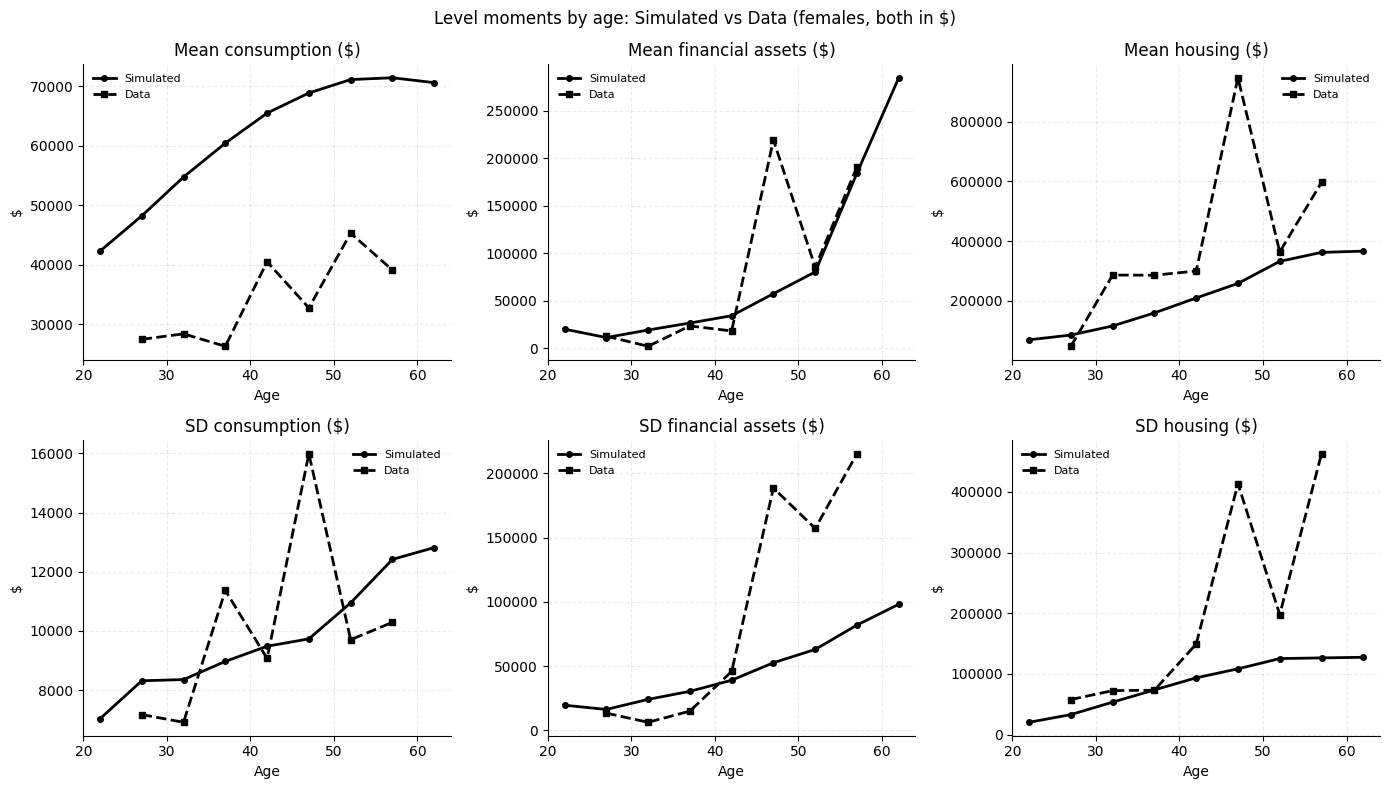

In [ ]:
# --- De-normalise simulated moments to dollar units ---
# normalisation = 1e-05 in settings.yaml, so model_units * 1e5 = dollars
# Level moments (means, SDs) scale linearly; correlations/autocorrelations are scale-free.

from examples.durables2_0.horses.simulate import _base_stage
_norm = 1.0 / float(_base_stage(nest).settings['normalisation'])
print(f'De-normalisation factor: {_norm:.0f}')

# Rescale level moments in sim_moments
sim_moments_dollar = {}
for k, v in sim_moments.items():
    is_level = any(k.startswith(p) for p in [
        'mean_c', 'mean_a', 'mean_h', 'sd_c', 'sd_a', 'sd_h',
        'av_', 'sd_consumption', 'sd_fin_assets', 'sd_wealth_real',
        'cond_discrete_0_mean_', 'cond_discrete_1_mean_',
    ])
    sim_moments_dollar[k] = v * _norm if (is_level and np.isfinite(v)) else v

# --- Panel 1: Level moments on same axis (both in dollars) ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

pairs = [
    ('mean_c', 'av_consumption2_14_0', 'Mean consumption ($)'),
    ('mean_a', 'av_fin_assets_14_0',   'Mean financial assets ($)'),
    ('mean_h', 'av_wealth_real_14_0',   'Mean housing ($)'),
    ('sd_c',   'sd_consumption2_14_0',  'SD consumption ($)'),
    ('sd_a',   'sd_fin_assets_14_0',    'SD financial assets ($)'),
    ('sd_h',   'sd_wealth_real_14_0',   'SD housing ($)'),
]

for ax, (sim_prefix, data_prefix, title) in zip(axes.flatten(), pairs):
    plot_moment_by_age(sim_moments_dollar, data_moments,
                       sim_prefix, title, '$',
                       data_prefix=data_prefix, ax=ax)

fig.suptitle('Level moments by age: Simulated vs Data (females, both in $)', fontsize=12)
fig.tight_layout()
plt.show()

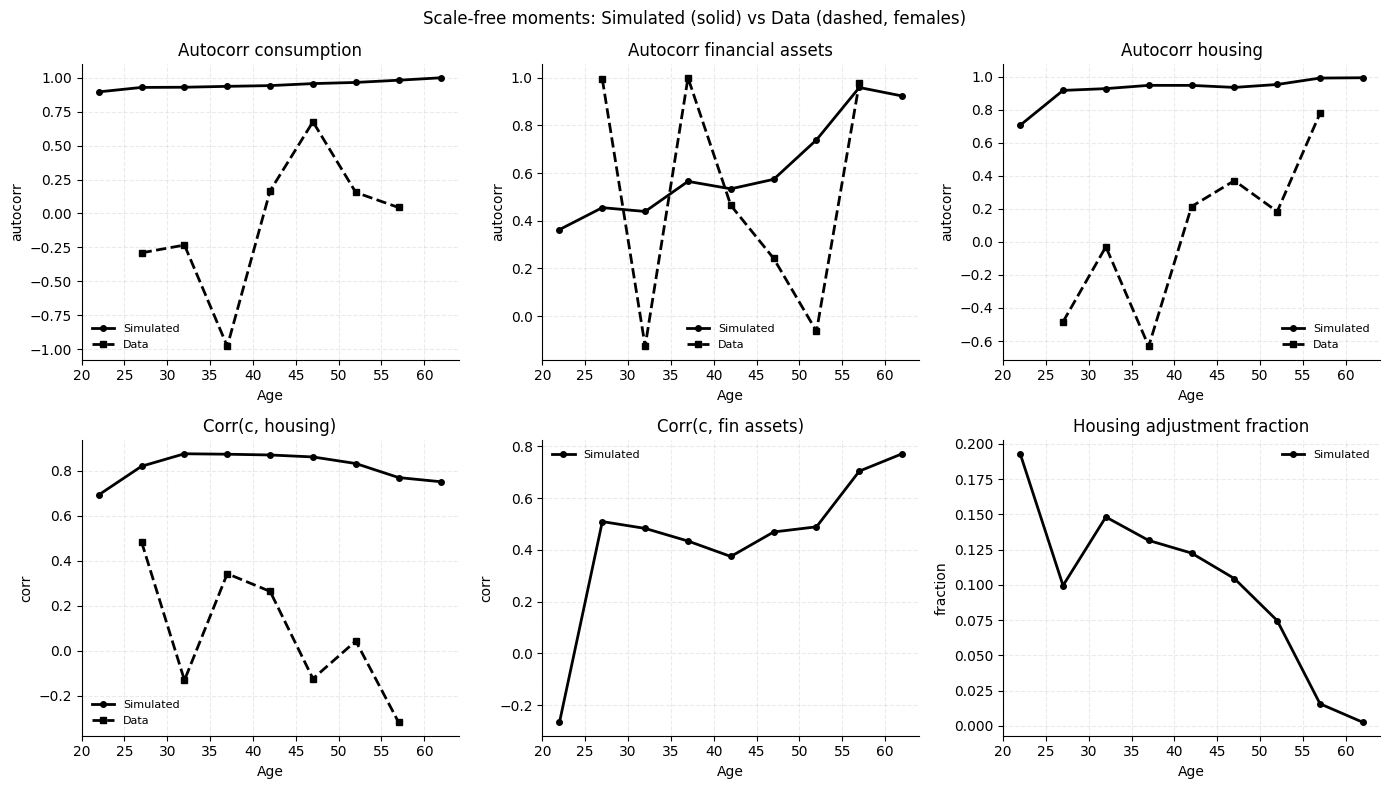

In [ ]:
# --- Panel 2: Scale-free moments (directly comparable, females _0) ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Autocorrelations — same scale, overlay directly
plot_moment_by_age(sim_moments, data_moments, 'autocorr_c', 'Autocorr consumption',
                   'autocorr', data_prefix='autocorr_consumption_0', ax=axes[0, 0])
plot_moment_by_age(sim_moments, data_moments, 'autocorr_a', 'Autocorr financial assets',
                   'autocorr', data_prefix='autocorr_wealth_fin_0', ax=axes[0, 1])
plot_moment_by_age(sim_moments, data_moments, 'autocorr_h', 'Autocorr housing',
                   'autocorr', data_prefix='autocorr_wealth_real_0', ax=axes[0, 2])

# Correlations
plot_moment_by_age(sim_moments, data_moments, 'corr_c_h', 'Corr(c, housing)',
                   'corr', data_prefix='corr_cons_realw_14_0', ax=axes[1, 0])
plot_moment_by_age(sim_moments, data_moments, 'corr_c_a', 'Corr(c, fin assets)',
                   'corr', ax=axes[1, 1])

# Adjustment fraction (sim only — no data counterpart)
plot_moment_by_age(sim_moments, {}, 'branch_frac_discrete_1',
                   'Housing adjustment fraction',
                   'fraction', ax=axes[1, 2])

fig.suptitle('Scale-free moments: Simulated (solid) vs Data (dashed, females)', fontsize=12)
fig.tight_layout()
plt.show()

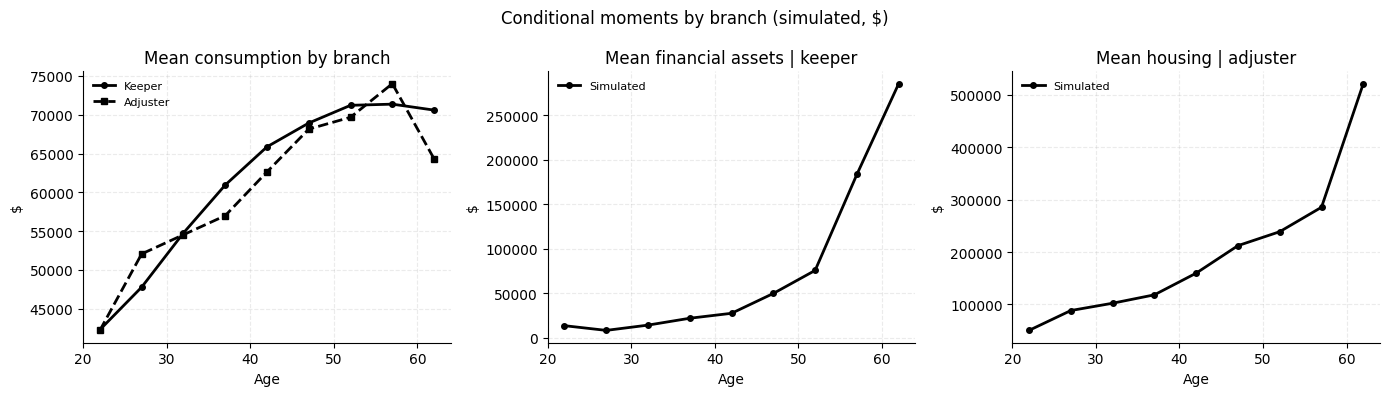

In [ ]:
# --- Panel 3: Conditional moments (keeper vs adjuster, in dollars) ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

plot_moment_by_age(sim_moments_dollar, {}, 'cond_discrete_0_mean_c',
                   'Mean c | keeper', '$', ax=axes[0],
                   sim_kw=dict(color='black', linestyle='-', linewidth=2,
                               marker='o', markersize=4, label='Keeper'))
plot_moment_by_age(sim_moments_dollar, {}, 'cond_discrete_1_mean_c',
                   '', '$', ax=axes[0],
                   sim_kw=dict(color='black', linestyle='--', linewidth=2,
                               marker='s', markersize=4, label='Adjuster'))
axes[0].set_title('Mean consumption by branch')
axes[0].legend(fontsize=8, frameon=False)

plot_moment_by_age(sim_moments_dollar, {}, 'cond_discrete_0_mean_a',
                   'Mean financial assets | keeper', '$', ax=axes[1])

plot_moment_by_age(sim_moments_dollar, {}, 'cond_discrete_1_mean_h',
                   'Mean housing | adjuster', '$', ax=axes[2])

fig.suptitle('Conditional moments by branch (simulated, $)', fontsize=12)
fig.tight_layout()
plt.show()

## 7. Summary table: all simulated moments

In [ ]:
import pandas as pd

# Build a tidy table of all simulated moments
rows = []
for k, v in sim_moments.items():
    parts = k.rsplit('__age', 1)
    moment_name = parts[0]
    age_group = int(parts[1]) if len(parts) > 1 and parts[1].isdigit() else None
    rows.append({
        'moment': moment_name,
        'age_group': age_group,
        'sim_value': v,
    })

df_sim = pd.DataFrame(rows)

# Pivot: moments as rows, age groups as columns
pivot = df_sim.pivot(index='moment', columns='age_group', values='sim_value')
pivot = pivot.round(4)

print(f'Simulated moments: {len(df_sim)} total ({len(pivot)} unique types x {pivot.shape[1]} age groups)')
print()
# Display with pandas (nice formatting in notebook)
pivot

Simulated moments: 261 total (29 unique types x 9 age groups)



age_group,1,2,3,4,5,6,7,8,9
moment,,,,,,,,,
autocorr_a,0.3628,0.4548,0.4387,0.5649,0.5337,0.5735,0.7391,0.9589,0.9233
autocorr_c,0.8959,0.9286,0.9300,0.9365,0.9421,0.9568,0.9653,0.9818,0.9998
autocorr_consumption_0,0.8959,0.9286,0.9300,0.9365,0.9421,0.9568,0.9653,0.9818,0.9998
autocorr_h,0.7059,0.9166,0.9274,0.9472,0.9471,0.9347,0.9525,0.9913,0.9932
autocorr_wealth_fin_0,0.3628,0.4548,0.4387,0.5649,0.5337,0.5735,0.7391,0.9589,0.9233
autocorr_wealth_real_0,0.7059,0.9166,0.9274,0.9472,0.9471,0.9347,0.9525,0.9913,0.9932
av_consumption2_14_0,0.4229,0.4821,0.5473,0.6042,0.6546,0.6884,0.7109,0.7140,0.7057
av_fin_assets_14_0,0.2033,0.1150,0.1943,0.2678,0.3444,0.5762,0.8053,1.8444,2.8477
av_wealth_real_14_0,0.7001,0.8581,1.1626,1.5991,2.0993,2.5861,3.3238,3.6245,3.6655
